# ZARA - Customer Segmentation (RFM + KMeans)

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

## Build the RFM table from Gold

In [ ]:
load_dotenv(dotenv_path="../src/.env")
engine = create_engine(os.getenv("DATABASE_URL"))

query = """
WITH snap AS (
    SELECT MAX(d.full_date) AS asof
    FROM gold.fact_sales f JOIN gold.dim_date d ON f.date_key = d.date_key
    WHERE f.source_system = 'batch'
)
SELECT
    f.customer_id,
    ((SELECT asof FROM snap) - MAX(d.full_date))::int AS recency_days,
    COUNT(DISTINCT f.order_id)                        AS frequency,
    SUM(f.net_amount)                                 AS monetary
FROM gold.fact_sales f
JOIN gold.dim_date d ON f.date_key = d.date_key
WHERE f.source_system = 'batch'
GROUP BY f.customer_id;
"""

rfm = pd.read_sql(query, engine)
print(rfm.shape)
rfm.describe().round(1)

## Preprocess - log-transform skew, then standardize

In [3]:
X = pd.DataFrame({
    "recency":   np.log1p(rfm["recency_days"]),
    "frequency": np.log1p(rfm["frequency"]),
    "monetary":  np.log1p(rfm["monetary"].clip(lower=0)),
})
Xs = StandardScaler().fit_transform(X)
Xs.shape

(20118, 3)

## Choose k - elbow + silhouette

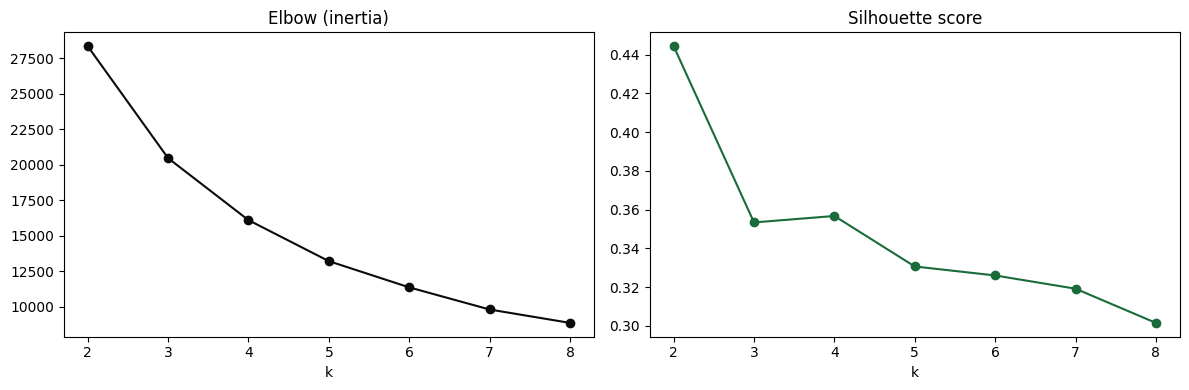

best k by silhouette: 2


In [4]:
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inertia, "o-", color="#0a0a0a"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sil, "o-", color="#1a6b3a"); ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()
print("best k by silhouette:", list(ks)[int(np.argmax(sil))])

## Fit the final model (k = 4)

In [5]:
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=42)
rfm["cluster"] = km.fit_predict(Xs)
rfm["cluster"].value_counts().sort_index()

cluster
0    6423
1    3906
2    3605
3    6184
Name: count, dtype: int64

## Profile & name the segments

In [6]:
profile = rfm.groupby("cluster").agg(
    customers=("customer_id", "count"),
    recency=("recency_days", "mean"),
    frequency=("frequency", "mean"),
    monetary=("monetary", "mean"),
).round(1)
profile

,customers,recency,frequency,monetary
cluster,,,,
0,6423,482.0,1.3,427.2
1,3906,36.8,15.5,6078.4
2,3605,26.9,3.7,1419.8
3,6184,253.2,4.2,1669.2


In [7]:
rank = profile.copy()
rank["score"] = (-rank["recency"]).rank() + rank["frequency"].rank() + rank["monetary"].rank()
order = rank["score"].sort_values(ascending=False).index.tolist()
names = ["Champions", "Loyal", "Potential", "At-Risk"]
label_map = {cl: names[i] for i, cl in enumerate(order)}
rfm["segment"] = rfm["cluster"].map(label_map)
profile_named = profile.rename(index=label_map).loc[names]
profile_named

,customers,recency,frequency,monetary
cluster,,,,
Champions,3906,36.8,15.5,6078.4
Loyal,3605,26.9,3.7,1419.8
Potential,6184,253.2,4.2,1669.2
At-Risk,6423,482.0,1.3,427.2


## Visualize the segments

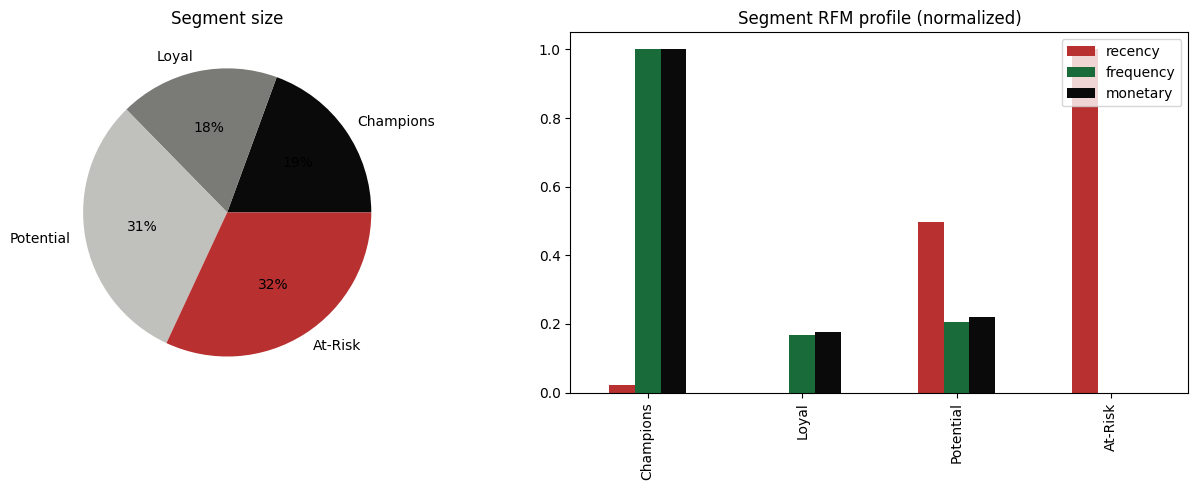

In [8]:
seg_size = rfm["segment"].value_counts().reindex(names)
colors = ["#0a0a0a", "#7a7a76", "#c0c0bc", "#b83030"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].pie(seg_size, labels=seg_size.index, autopct="%1.0f%%", colors=colors)
ax[0].set_title("Segment size")

prof = profile_named[["recency", "frequency", "monetary"]]
prof_norm = (prof - prof.min()) / (prof.max() - prof.min())
prof_norm.plot(kind="bar", ax=ax[1], color=["#b83030", "#1a6b3a", "#0a0a0a"])
ax[1].set_title("Segment RFM profile (normalized)"); ax[1].set_xlabel("")
ax[1].legend(loc="upper right")
plt.tight_layout(); plt.show()

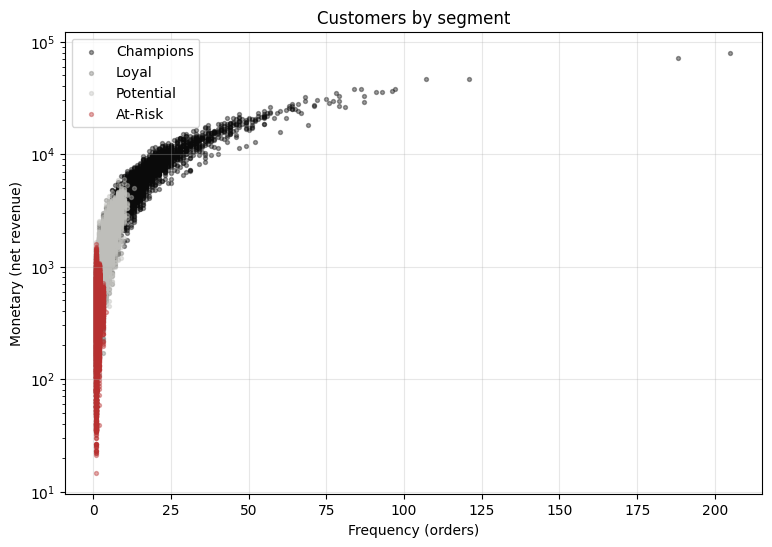

In [9]:
# Frequency vs Monetary, colored by segment
plt.figure(figsize=(9, 6))
for seg, color in zip(names, colors):
    d = rfm[rfm["segment"] == seg]
    plt.scatter(d["frequency"], d["monetary"], s=8, alpha=.4, label=seg, color=color)
plt.xlabel("Frequency (orders)"); plt.ylabel("Monetary (net revenue)")
plt.yscale("log"); plt.title("Customers by segment"); plt.legend(); plt.grid(alpha=.3)
plt.show()

## Business read-out
- **Champions** — recent, frequent, high spend. Reward with early access / loyalty perks; protect them.
- **Loyal** — solid frequency & spend. Upsell and cross-sell; nudge toward Champion behaviour.
- **Potential** — promising but not yet committed. Onboarding journeys and targeted offers.
- **At-Risk** — high recency (haven't bought in a while). Win-back campaigns and reactivation discounts.

The `rfm` dataframe now carries a `segment` label per customer and can be written back to the warehouse or joined into Power BI for segment-level dashboards.